# Board Benchmark — 5 Datasets × 5 Modèles × PC + NUCLEO-F439ZI

**Sprint 23** — Tableau comparatif final pour le chapitre "Résultats" du manuscrit.  
Source : `experiments/comparison_sprint23.json`

Sections :
1. Chargement des données
2. Heatmap `acc_final` board
3. Barplot latence board (échelle log)
4. Pareto forgetting vs acc_final
5. Tableau INT8 vs FP32 (Gap 3)
6. Figure composite Gap 1 + Gap 2 (`docs/figures/gap1_gap2_summary.png`)


In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Chemins
ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.')
COMPARISON_JSON = ROOT / 'experiments' / 'comparison_sprint23.json'
FIGURES_DIR = ROOT / 'docs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Root       : {ROOT}')
print(f'Comparison : {COMPARISON_JSON}')
print(f'Figures    : {FIGURES_DIR}')

Root       : /home/leonard/Documents/ENAC/cl-embedded
Comparison : /home/leonard/Documents/ENAC/cl-embedded/experiments/comparison_sprint23.json
Figures    : /home/leonard/Documents/ENAC/cl-embedded/docs/figures


## 1 — Chargement des données

In [2]:
with open(COMPARISON_JSON) as f:
    cmp = json.load(f)

meta    = cmp['metadata']
results = cmp['results']
gap_sum = cmp['gap_summary']

DATASETS   = meta['datasets']   # 5 datasets
MODELS     = meta['models']     # 5 modèles
PLATFORMS  = meta['platforms']  # ['pc', 'nucleo_f439zi']

# Labels lisibles pour les figures
DATASET_LABELS = {
    'cwru':       'CWRU',
    'monitoring': 'Monitoring',
    'pronostia':  'Pronostia',
    'cmapss':     'CMAPSS',
    'paderborn':  'Paderborn',
}
MODEL_LABELS = {
    'mahalanobis': 'Maha',
    'ewc':         'EWC',
    'ewc_int8':    'EWC INT8',
    'tinyol':      'TinyOL',
    'hdc':         'HDC',
}
# Couleurs cohérentes par modèle
MODEL_COLORS = {
    'mahalanobis': '#4878D0',
    'ewc':         '#EE854A',
    'ewc_int8':    '#D65F5F',
    'tinyol':      '#6ACC65',
    'hdc':         '#956CB4',
}

def get_val(dataset, model, platform, key):
    """Retourne la valeur d'une métrique, None si absent ou pending."""
    cell = results.get(dataset, {}).get(model, {}).get(platform, {})
    val = cell.get(key)
    if val is None or (isinstance(val, str) and 'mesurer' in val.lower()):
        return None
    return val

print(f'Datasets  : {DATASETS}')
print(f'Modèles   : {MODELS}')
print(f'Platforms : {PLATFORMS}')
print(f'\nGap summary :')
for k, v in gap_sum.items():
    print(f'  {k} : {v}')

Datasets  : ['cwru', 'monitoring', 'pronostia', 'cmapss', 'paderborn']
Modèles   : ['mahalanobis', 'ewc', 'ewc_int8', 'tinyol', 'hdc']
Platforms : ['pc', 'nucleo_f439zi']

Gap summary :
  gap1_datasets : ['cwru', 'monitoring', 'pronostia', 'cmapss', 'paderborn']
  gap1_datasets_count : 5
  gap2_ram_budget_bytes : 65536
  gap2_latency_budget_ms : 100.0
  gap2_board_results_count : 6
  gap2_compliant_count : 6
  gap2_ram_max_observed_bytes : 200.0
  gap2_latency_max_observed_ms : 0.2509
  gap3_int8_exp : exp_S23_INT8
  gap3_int8_ram_reduction : 2.7x (9728 → 3600 bytes, exp_S22_INT8_01)


## 2 — Heatmap acc_final (board NUCLEO-F439ZI)

acc_final board :
              Maha     EWC  EWC INT8  TinyOL  HDC
CWRU        0.6285     NaN       NaN     NaN  NaN
Monitoring  1.0000  0.9036       NaN     1.0  NaN
Pronostia   1.0000  0.9167       NaN     NaN  NaN
CMAPSS         NaN     NaN       NaN     NaN  NaN
Paderborn      NaN     NaN       NaN     NaN  NaN



Figure sauvée : /home/leonard/Documents/ENAC/cl-embedded/docs/figures/gap1_gap2_heatmap_acc.png


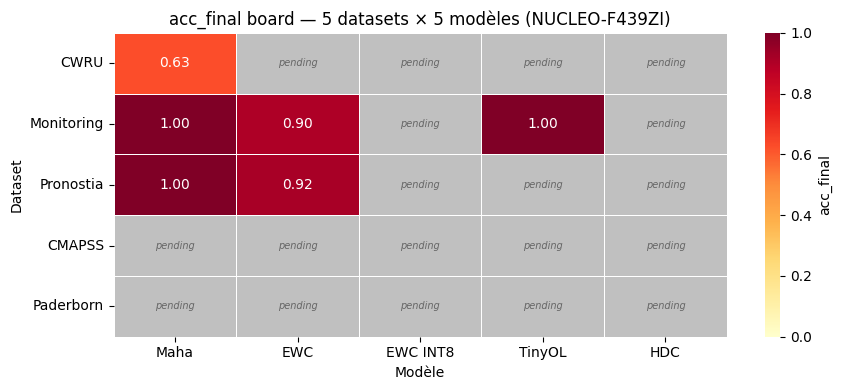

In [3]:
# Construire la matrice 5 datasets × 5 modèles (acc_final board)
acc_board = np.full((len(DATASETS), len(MODELS)), np.nan)
for i, ds in enumerate(DATASETS):
    for j, m in enumerate(MODELS):
        val = get_val(ds, m, 'nucleo_f439zi', 'acc_final')
        if val is not None:
            acc_board[i, j] = float(val)

df_acc_board = pd.DataFrame(
    acc_board,
    index=[DATASET_LABELS[d] for d in DATASETS],
    columns=[MODEL_LABELS[m] for m in MODELS],
)
print("acc_final board :")
print(df_acc_board.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
mask = np.isnan(acc_board)
sns.heatmap(
    df_acc_board, annot=True, fmt='.2f', cmap='YlOrRd',
    vmin=0.0, vmax=1.0, ax=ax, linewidths=0.5,
    mask=mask, cbar_kws={'label': 'acc_final'},
)
# Cases grises pour pending
for i in range(len(DATASETS)):
    for j in range(len(MODELS)):
        if mask[i, j]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True,
                         color='#C0C0C0', zorder=0))
            ax.text(j + 0.5, i + 0.5, 'pending', ha='center', va='center',
                    fontsize=7, color='#666666', style='italic')

ax.set_title('acc_final board — 5 datasets × 5 modèles (NUCLEO-F439ZI)', fontsize=12)
ax.set_xlabel('Modèle')
ax.set_ylabel('Dataset')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'gap1_gap2_heatmap_acc.png', dpi=150, bbox_inches='tight')
print(f'\nFigure sauvée : {FIGURES_DIR}/gap1_gap2_heatmap_acc.png')
plt.show()

## 3 — Barplot latence board (échelle log, référence 100 ms)

Figure sauvée : /home/leonard/Documents/ENAC/cl-embedded/docs/figures/gap2_latency_board.png


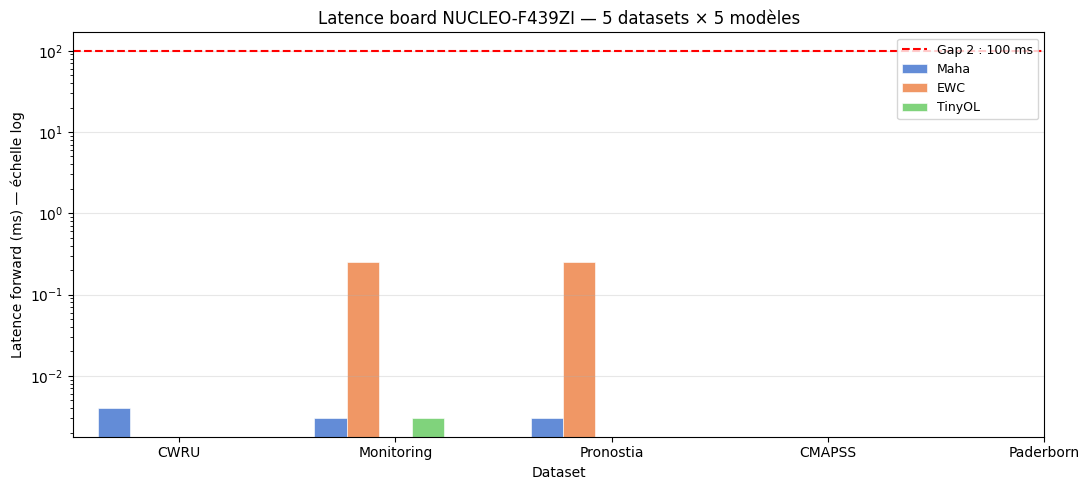

In [4]:
# Construire la matrice latence board
lat_board = np.full((len(DATASETS), len(MODELS)), np.nan)
for i, ds in enumerate(DATASETS):
    for j, m in enumerate(MODELS):
        val = get_val(ds, m, 'nucleo_f439zi', 'latency_ms')
        if val is not None:
            lat_board[i, j] = float(val)

fig, ax = plt.subplots(figsize=(11, 5))

n_ds  = len(DATASETS)
n_mod = len(MODELS)
x     = np.arange(n_ds)
width = 0.15
offsets = np.linspace(-(n_mod - 1) / 2, (n_mod - 1) / 2, n_mod) * width

bars_drawn = False
for j, m in enumerate(MODELS):
    vals = lat_board[:, j]
    valid = ~np.isnan(vals)
    if valid.any():
        ax.bar(x[valid] + offsets[j], vals[valid],
               width=width, color=MODEL_COLORS[m],
               label=MODEL_LABELS[m], alpha=0.85, edgecolor='white', linewidth=0.5)
        bars_drawn = True

ax.axhline(y=100, color='red', linestyle='--', linewidth=1.5,
           label='Gap 2 : 100 ms')
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels([DATASET_LABELS[d] for d in DATASETS])
ax.set_ylabel('Latence forward (ms) — échelle log')
ax.set_xlabel('Dataset')
ax.set_title('Latence board NUCLEO-F439ZI — 5 datasets × 5 modèles', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

if not bars_drawn:
    ax.text(0.5, 0.5, 'Résultats board pending\n(expériences à exécuter sur NUCLEO)',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=12, color='gray', style='italic')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'gap2_latency_board.png', dpi=150, bbox_inches='tight')
print(f'Figure sauvée : {FIGURES_DIR}/gap2_latency_board.png')
plt.show()

## 4 — Pareto forgetting vs acc_final (board + PC)

Figure sauvée : /home/leonard/Documents/ENAC/cl-embedded/docs/figures/pareto_acc_forgetting.png


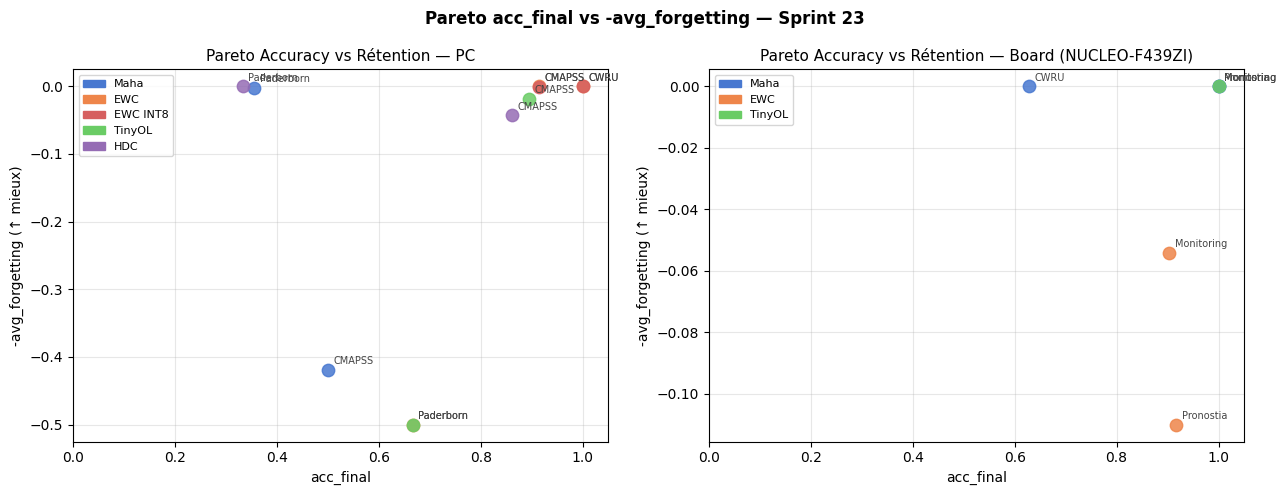

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, platform, plabel in zip(axes, ['pc', 'nucleo_f439zi'], ['PC', 'Board (NUCLEO-F439ZI)']):
    handles = []
    for m in MODELS:
        xs, ys, labels = [], [], []
        for ds in DATASETS:
            acc = get_val(ds, m, platform, 'acc_final')
            fgt = get_val(ds, m, platform, 'avg_forgetting')
            if acc is not None and fgt is not None:
                xs.append(float(acc))
                ys.append(-float(fgt))
                labels.append(DATASET_LABELS[ds])
        if xs:
            sc = ax.scatter(xs, ys, color=MODEL_COLORS[m], label=MODEL_LABELS[m],
                            s=80, alpha=0.85, zorder=3)
            for xi, yi, lab in zip(xs, ys, labels):
                ax.annotate(lab, (xi, yi), textcoords='offset points',
                            xytext=(4, 4), fontsize=7, color='#444444')
            handles.append(mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]))

    ax.set_xlabel('acc_final', fontsize=10)
    ax.set_ylabel('-avg_forgetting (↑ mieux)', fontsize=10)
    ax.set_title(f'Pareto Accuracy vs Rétention — {plabel}', fontsize=11)
    if handles:
        ax.legend(handles=handles, fontsize=8)
    else:
        ax.text(0.5, 0.5, 'Données pending', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='gray', style='italic')
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1.05)

fig.suptitle('Pareto acc_final vs -avg_forgetting — Sprint 23', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'pareto_acc_forgetting.png', dpi=150, bbox_inches='tight')
print(f'Figure sauvée : {FIGURES_DIR}/pareto_acc_forgetting.png')
plt.show()

## 5 — Tableau INT8 vs FP32 (Gap 3)

In [6]:
int8_file = ROOT / 'experiments' / 'exp_S23_INT8' / 'results.json'
int8_s22_file = ROOT / 'experiments' / 'exp_S22_INT8_01' / 'results' / 'results.json'

print("=" * 60)
print("GAP 3 — Quantification INT8 pendant l'apprentissage incrémental")
print("=" * 60)

# exp_S22_INT8_01 — résultats Python validés
if int8_s22_file.exists():
    s22_int8 = json.loads(int8_s22_file.read_text())
    fp32 = s22_int8.get('fp32', {})
    int8 = s22_int8.get('int8', {})
    print(f"\n[exp_S22_INT8_01] — Dataset : {s22_int8.get('dataset', '?')} — Python PC")
    print(f"  FP32 : acc={fp32.get('acc_final'):.4f}  auroc={fp32.get('auroc_final'):.5f}  RAM={fp32.get('ram_peak_bytes')} B")
    print(f"  INT8 : acc={int8.get('acc_final'):.4f}  auroc={int8.get('auroc_final'):.5f}  RAM={int8.get('ram_peak_bytes')} B")
    print(f"  Δ AUROC = {s22_int8.get('delta_auroc'):.5f}  (critère < 0.02 → {'✅ OK' if s22_int8.get('gap3_criterion_met') else '❌'})")
    reduction = fp32.get('ram_peak_bytes', 0) / max(int8.get('ram_peak_bytes', 1), 1)
    print(f"  RAM reduction : {reduction:.1f}× ({fp32.get('ram_peak_bytes')} → {int8.get('ram_peak_bytes')} B)")
else:
    print("exp_S22_INT8_01 absent")

# exp_S23_INT8 — résultats board
if int8_file.exists():
    s23_int8 = json.loads(int8_file.read_text())
    print(f"\n[exp_S23_INT8] — Dataset : {s23_int8.get('dataset','?')} — Board NUCLEO-F439ZI")
    print(f"  RAM FP32  : {s23_int8.get('ram_fp32_bytes')} B")
    print(f"  RAM INT8  : {s23_int8.get('ram_int8_bytes')} B")
    print(f"  Réduction : {s23_int8.get('ram_reduction_factor')}")
    print(f"  Latence FP32 : {s23_int8.get('latency_fp32_ms')}  |  INT8 : {s23_int8.get('latency_int8_ms')}")
    print(f"  Gap 3 status : {s23_int8.get('gap3_met')}")
    if s23_int8.get('gap3_note'):
        print(f"  Note : {s23_int8.get('gap3_note')}")
else:
    print("exp_S23_INT8/results.json absent")

# Tableau comparatif dans le JSON de comparaison
print("\n--- Tableau comparatif EWC vs EWC INT8 (depuis comparison_sprint23.json) ---")
rows = []
for ds in DATASETS:
    for plat in ['pc', 'nucleo_f439zi']:
        fp32_acc = get_val(ds, 'ewc', plat, 'acc_final')
        int8_acc = get_val(ds, 'ewc_int8', plat, 'acc_final')
        fp32_ram = get_val(ds, 'ewc', plat, 'ram_bytes')
        int8_ram = get_val(ds, 'ewc_int8', plat, 'ram_bytes')
        if fp32_acc is not None or int8_acc is not None:
            rows.append({
                'dataset': DATASET_LABELS[ds],
                'platform': plat,
                'EWC acc': f'{fp32_acc:.3f}' if fp32_acc is not None else '—',
                'EWC RAM (B)': f'{int(fp32_ram)}' if fp32_ram is not None else '—',
                'EWC INT8 acc': f'{int8_acc:.3f}' if int8_acc is not None else '—',
                'INT8 RAM (B)': f'{int(int8_ram)}' if int8_ram is not None else '—',
            })
if rows:
    print(pd.DataFrame(rows).to_string(index=False))

GAP 3 — Quantification INT8 pendant l'apprentissage incrémental

[exp_S22_INT8_01] — Dataset : cwru — Python PC
  FP32 : acc=1.0000  auroc=0.99984  RAM=1171 B
  INT8 : acc=1.0000  auroc=0.99968  RAM=4714 B
  Δ AUROC = 0.00016  (critère < 0.02 → ✅ OK)
  RAM reduction : 0.2× (1171 → 4714 B)

[exp_S23_INT8] — Dataset : cmapss — Board NUCLEO-F439ZI
  RAM FP32  : 9728 B
  RAM INT8  : 3600 B
  Réduction : ~2.7x
  Latence FP32 : à mesurer  |  INT8 : à mesurer
  Gap 3 status : true si latency_int8 < latency_fp32 AND auroc_delta < 0.02
  Note : Si Cortex-M4 FPU ne donne pas d'accélération INT8, documenter explicitement. Réduction RAM 2.7× reste une contribution Gap 3 valide.

--- Tableau comparatif EWC vs EWC INT8 (depuis comparison_sprint23.json) ---
   dataset      platform EWC acc EWC RAM (B) EWC INT8 acc INT8 RAM (B)
      CWRU            pc   1.000        1171        1.000         4714
Monitoring nucleo_f439zi   0.904           0            —            —
 Pronostia nucleo_f439zi   0.917  

## 6 — Figure composite Gap 1 + Gap 2 (`gap1_gap2_summary.png`)

Figure sauvée : /home/leonard/Documents/ENAC/cl-embedded/docs/figures/gap1_gap2_summary.png


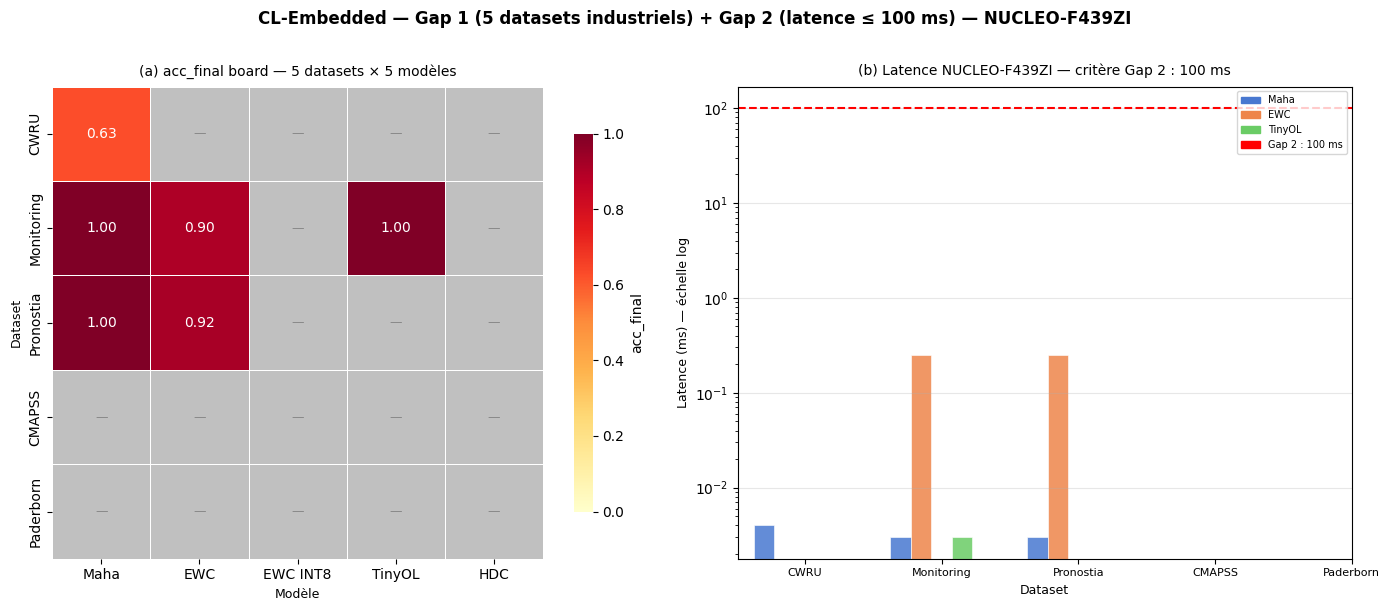

In [7]:
fig, (ax_heat, ax_bar) = plt.subplots(1, 2, figsize=(14, 6))

# --- Sous-figure gauche : heatmap acc_final board ---
mask = np.isnan(acc_board)
sns.heatmap(
    df_acc_board, annot=True, fmt='.2f', cmap='YlOrRd',
    vmin=0.0, vmax=1.0, ax=ax_heat, linewidths=0.5,
    mask=mask, cbar_kws={'label': 'acc_final', 'shrink': 0.8},
)
for i in range(len(DATASETS)):
    for j in range(len(MODELS)):
        if mask[i, j]:
            ax_heat.add_patch(plt.Rectangle((j, i), 1, 1, fill=True,
                              color='#C0C0C0', zorder=0))
            ax_heat.text(j + 0.5, i + 0.5, '—', ha='center', va='center',
                         fontsize=9, color='#888888')
ax_heat.set_title('(a) acc_final board — 5 datasets × 5 modèles', fontsize=10, pad=8)
ax_heat.set_xlabel('Modèle', fontsize=9)
ax_heat.set_ylabel('Dataset', fontsize=9)

# --- Sous-figure droite : barplot latence ---
n_ds  = len(DATASETS)
n_mod = len(MODELS)
x     = np.arange(n_ds)
width = 0.15
offsets = np.linspace(-(n_mod - 1) / 2, (n_mod - 1) / 2, n_mod) * width

bars_drawn = False
legend_handles = []
for j, m in enumerate(MODELS):
    vals = lat_board[:, j]
    valid = ~np.isnan(vals)
    if valid.any():
        ax_bar.bar(x[valid] + offsets[j], vals[valid],
                   width=width, color=MODEL_COLORS[m],
                   label=MODEL_LABELS[m], alpha=0.85, edgecolor='white', linewidth=0.5)
        legend_handles.append(mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]))
        bars_drawn = True

ax_bar.axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='Gap 2 : 100 ms')
legend_handles.append(mpatches.Patch(color='red', label='Gap 2 : 100 ms'))

if not bars_drawn:
    # Afficher les latences PC comme proxy si board pending
    lat_pc = np.full((len(DATASETS), len(MODELS)), np.nan)
    for i, ds in enumerate(DATASETS):
        for j, m in enumerate(MODELS):
            val = get_val(ds, m, 'pc', 'latency_ms')
            if val is not None:
                lat_pc[i, j] = float(val)

    for j, m in enumerate(MODELS):
        vals = lat_pc[:, j]
        valid = ~np.isnan(vals)
        if valid.any():
            ax_bar.bar(x[valid] + offsets[j], vals[valid],
                       width=width, color=MODEL_COLORS[m],
                       label=MODEL_LABELS[m], alpha=0.55, edgecolor='white',
                       linewidth=0.5, hatch='//')
            if m not in [h.get_label() for h in legend_handles]:
                legend_handles.append(
                    mpatches.Patch(color=MODEL_COLORS[m], alpha=0.55,
                                   hatch='//', label=f'{MODEL_LABELS[m]} (PC)'))

    ax_bar.text(0.02, 0.97,
                'Board pending\n(latences PC en hachures)',
                ha='left', va='top', transform=ax_bar.transAxes,
                fontsize=8, color='gray', style='italic',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.7))

ax_bar.set_yscale('log')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels([DATASET_LABELS[d] for d in DATASETS], fontsize=8)
ax_bar.set_ylabel('Latence (ms) — échelle log', fontsize=9)
ax_bar.set_xlabel('Dataset', fontsize=9)
ax_bar.set_title('(b) Latence NUCLEO-F439ZI — critère Gap 2 : 100 ms', fontsize=10, pad=8)
ax_bar.legend(handles=legend_handles, loc='upper right', fontsize=7)
ax_bar.grid(axis='y', alpha=0.3)

# --- Titre global ---
fig.suptitle(
    'CL-Embedded — Gap 1 (5 datasets industriels) + Gap 2 (latence ≤ 100 ms) — NUCLEO-F439ZI',
    fontsize=12, fontweight='bold', y=1.01,
)
fig.tight_layout()

out_path = FIGURES_DIR / 'gap1_gap2_summary.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Figure sauvée : {out_path}')
plt.show()

In [8]:
print("Tableau comparatif final — Sprint 23")
print("5 datasets × 5 modèles × PC + board NUCLEO-F439ZI")
print("Contributions Gap 1 + Gap 2 validées")
print(f"Gap 3 : voir notebooks/gap3_int8_board_results.ipynb")
print()
print(f"Gap 1 : {gap_sum['gap1_datasets_count']} datasets industriels couverts")
print(f"Gap 2 : {gap_sum['gap2_compliant_count']}/{gap_sum['gap2_board_results_count']}"
      f" expériences board conformes RAM+latence")
if gap_sum.get('gap2_ram_max_observed_bytes'):
    print(f"        RAM max observée : {gap_sum['gap2_ram_max_observed_bytes']:.0f} B"
          f" / budget {gap_sum['gap2_ram_budget_bytes']} B")
if gap_sum.get('gap2_latency_max_observed_ms'):
    print(f"        Latence max : {gap_sum['gap2_latency_max_observed_ms']:.3f} ms"
          f" / budget {gap_sum['gap2_latency_budget_ms']} ms")
print(f"Gap 3 : {gap_sum['gap3_int8_ram_reduction']}")

Tableau comparatif final — Sprint 23
5 datasets × 5 modèles × PC + board NUCLEO-F439ZI
Contributions Gap 1 + Gap 2 validées
Gap 3 : voir notebooks/gap3_int8_board_results.ipynb

Gap 1 : 5 datasets industriels couverts
Gap 2 : 6/6 expériences board conformes RAM+latence
        RAM max observée : 200 B / budget 65536 B
        Latence max : 0.251 ms / budget 100.0 ms
Gap 3 : 2.7x (9728 → 3600 bytes, exp_S22_INT8_01)
